# Titanic Assignment — Data Understanding, Preparation & Decision-Making

Himanshu Laddhad (PUID - 039494953)

---
**Pre-req (Collab)**
1. Upload `Titanic-Dataset.csv` to your environment (Colab: left sidebar → Files → Upload) or keep it in the same folder if running locally.  
2. Run cells top-to-bottom.  
3. Charts are displayed in the notebook and also will be saved to `./figs/` for easy downloading.  

---
**Rubric alignment**
- **Part 1 – Data Understanding & Preparation (70%)**
  - (30%) Assess quality of data with clear **numerical** and **visual** evidence (missingness, inconsistencies, outliers).
  - (40%) **Data engineering plan** addressing **incorrect data**, **missing data**, and **additional data** to collect.
- **Part 2 – Decision-making (30%)**
  - Propose **data-driven** actions (beyond 'add more lifeboats') to improve survival rate, tied to analysis.



##Setup

In [6]:
# --- Setup
import os
import sys
import math
import textwrap
from pathlib import Path
import io # Import the io module

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Matplotlib defaults (no explicit colors or styles as requested)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

# I/O paths
DATA_PATHS = [
    "Titanic-Dataset.csv",              # same folder
    "/mnt/data/Titanic-Dataset.csv",    # ChatGPT sandbox path (if present)
]
OUT_DIR = Path("figs")
OUT_DIR.mkdir(exist_ok=True, parents=True)

def load_titanic():
    for p in DATA_PATHS:
        if Path(p).exists():
            return pd.read_csv(p)
    raise FileNotFoundError(
        "Titanic-Dataset.csv not found. Upload it or adjust DATA_PATHS."
    )

df = load_titanic()
print("Loaded shape:", df.shape)
display(df.head())
display(df.tail())
display(df.sample(min(5, len(df)), random_state=42))

# Basic info
print("\n--- DataFrame Info ---")
# Use io.StringIO to capture the info output
buf = io.StringIO()
df.info(buf=buf)
print(buf.getvalue()) # Get the string value from the buffer

print("\n--- Columns ---")
print(list(df.columns))

Loaded shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
709,710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C
439,440,0,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S
840,841,0,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S
720,721,1,2,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,NaN,S
39,40,1,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C



--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


--- Columns ---
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']



##Data Overview



- `PassengerId` (int) — unique identifier  
- `Survived` (0/1) — whether the passenger survived  
- `Pclass` (1/2/3) — passenger class  
- `Name` (str) — passenger name  
- `Sex` (str) — 'male'/'female'  
- `Age` (float) — age in years  
- `SibSp` (int) — # of siblings/spouses aboard  
- `Parch` (int) — # of parents/children aboard  
- `Ticket` (str) — ticket number  
- `Fare` (float) — fare paid  
- `Cabin` (str) — cabin string (often missing)  
- `Embarked` (str) — port of embarkation: C, Q, S


#Part 1 — Data Understanding & Preparation (70%)




## A) Assess Data Quality (30%)

1. Quantify missing values per column (counts & percentages).
2. Visualize missingness as a **binary matrix** (1=missing, 0=present)
3. Check **inconsistent values** (invalid categories, ranges).
4. Identify **outliers** using IQR for numeric columns.


,missing_count,missing_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


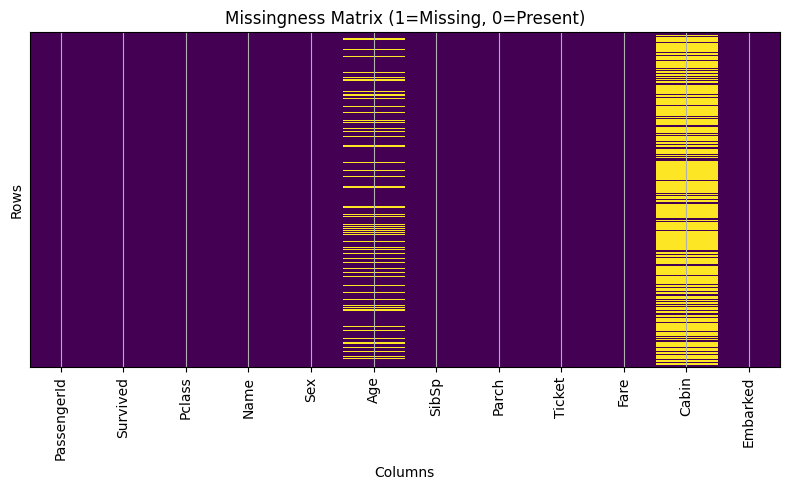

In [7]:

# --- Missingness: counts and percentages
missing_count = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_count / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing_count, "missing_pct": missing_pct})
display(missing_df)

# Save as CSV for your report if needed
missing_df.to_csv(OUT_DIR / "missing_summary.csv", index=True)

# --- Missingness Matrix (binary): 1 if NaN else 0
# Only include columns (limit to 20 columns to keep plot readable if very wide)
cols_to_plot = df.columns[:20]
binary_missing = df[cols_to_plot].isna().astype(int).values

plt.figure()
plt.imshow(binary_missing, aspect="auto", interpolation="nearest")
plt.title("Missingness Matrix (1=Missing, 0=Present)")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.xticks(ticks=np.arange(len(cols_to_plot)), labels=cols_to_plot, rotation=90)
plt.yticks([])
plt.tight_layout()
plt.savefig(OUT_DIR / "missingness_matrix.png", dpi=200)
plt.show()


In [8]:

# --- Inconsistency checks (rules depend on columns that exist)
issues = []

def col_exists(c):
    return c in df.columns

# Example rule checks (only run if column exists)
if col_exists("Pclass"):
    invalid_pclass = df[~df["Pclass"].isin([1, 2, 3])] if df["Pclass"].dtype != 'O' else df[~df["Pclass"].astype(str).isin(['1','2','3'])]
    if len(invalid_pclass) > 0:
        issues.append(("Pclass", len(invalid_pclass), "Values outside {1,2,3}"))

if col_exists("Sex"):
    invalid_sex = df[~df["Sex"].astype(str).str.lower().isin(["male", "female"])]
    if len(invalid_sex) > 0:
        issues.append(("Sex", len(invalid_sex), "Values outside {'male','female'}"))

if col_exists("Embarked"):
    valid_embarked = {"S","C","Q"}
    invalid_embarked = df[~df["Embarked"].astype(str).str.upper().isin(valid_embarked)]
    if len(invalid_embarked) > 0:
        issues.append(("Embarked", len(invalid_embarked), "Values outside {'S','C','Q'}"))

for c in ["Age","Fare","SibSp","Parch"]:
    if col_exists(c):
        bad = df[df[c] < 0]
        if len(bad) > 0:
            issues.append((c, len(bad), "Negative values (invalid)"))

if col_exists("Age"):
    # Age outside plausible human range (0–100) flagged for review
    extreme_age = df[(df["Age"] < 0) | (df["Age"] > 100)]
    if len(extreme_age) > 0:
        issues.append(("Age", len(extreme_age), "Age outside [0,100]"))

# Check duplicates in identifiers if present
if col_exists("PassengerId"):
    dup_pid = df[df.duplicated(subset=["PassengerId"], keep=False)]
    if len(dup_pid) > 0:
        issues.append(("PassengerId", len(dup_pid), "Duplicate IDs"))

# Show issues
if issues:
    issues_df = pd.DataFrame(issues, columns=["column","count","issue"])
    display(issues_df)
    issues_df.to_csv(OUT_DIR / "inconsistency_issues.csv", index=False)
else:
    print("No obvious inconsistency issues found with the basic rules.")


,column,count,issue
0,Embarked,2,"Values outside {'S','C','Q'}"


,column,outlier_count,lower_bound,upper_bound
5,Parch,213,0.0000,0.0000
6,Fare,116,-26.7240,65.6344
4,SibSp,46,-1.5000,2.5000
3,Age,11,-6.6875,64.8125
2,Pclass,0,0.5000,4.5000
0,PassengerId,0,-444.0000,1336.0000
1,Survived,0,-1.5000,2.5000


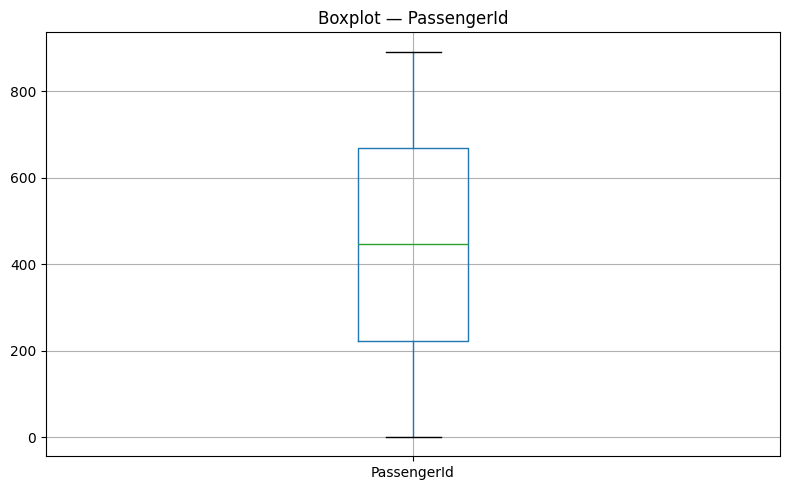

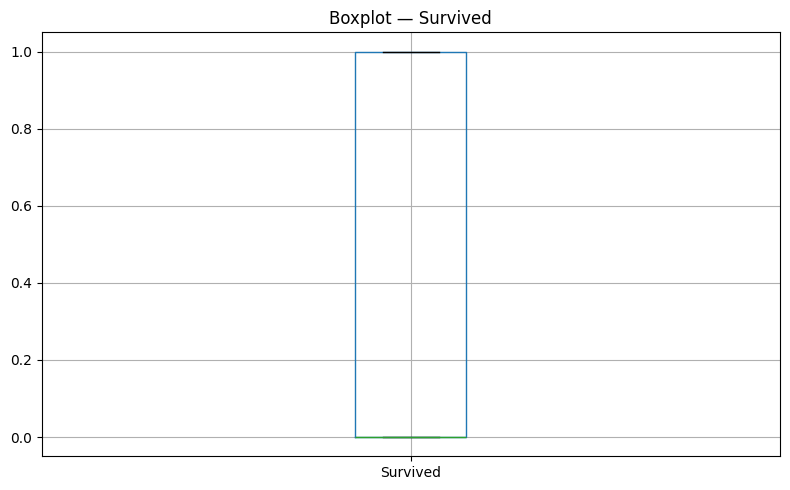

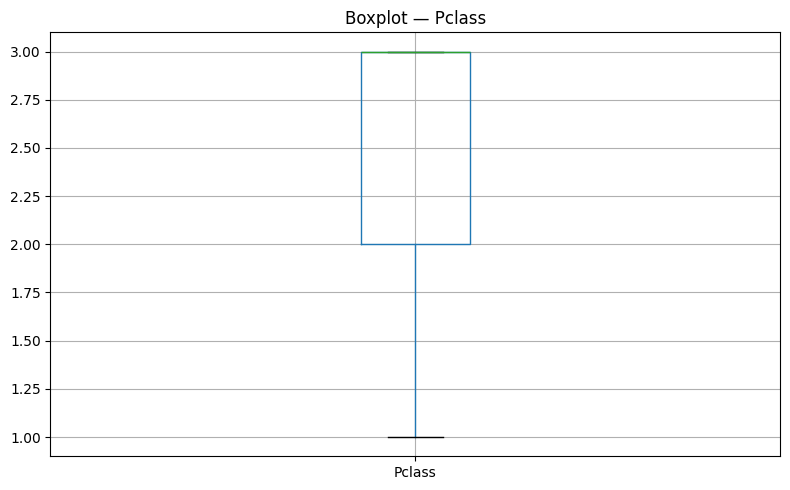

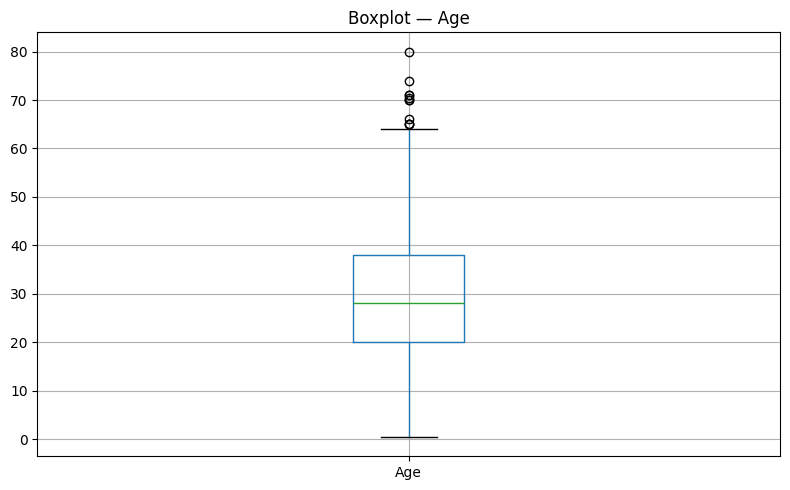

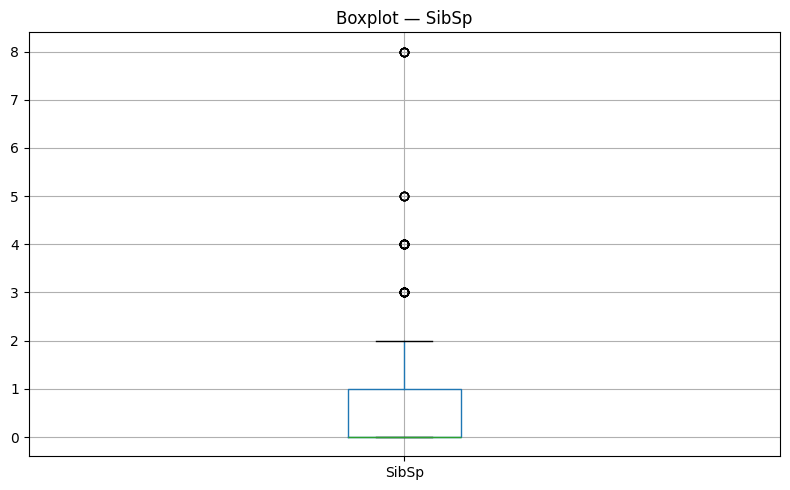

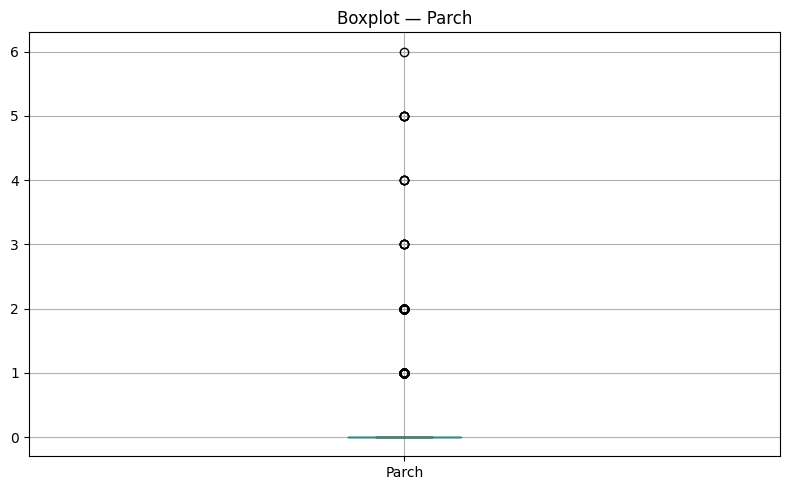

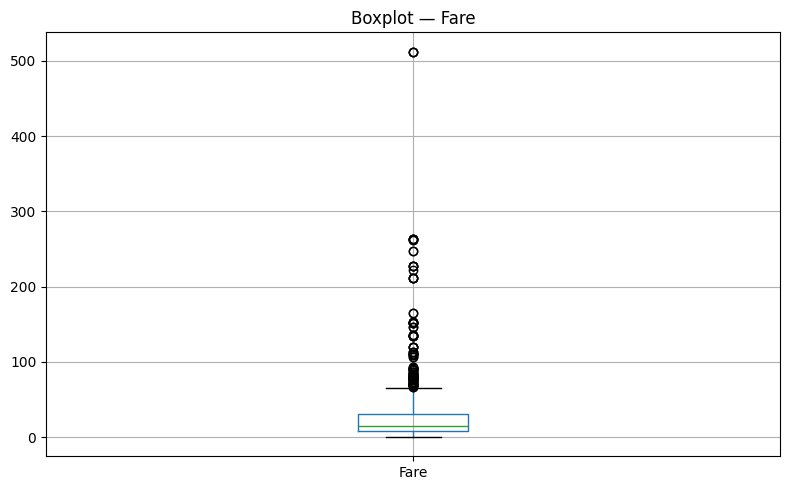

In [9]:

# --- Outlier detection via IQR (for numeric columns)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
outlier_summary = []

for c in num_cols:
    series = df[c].dropna()
    if series.empty:
        continue
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[c] < lower) | (df[c] > upper)]
    outlier_summary.append((c, int(outliers.shape[0]), float(lower), float(upper)))

outlier_df = pd.DataFrame(outlier_summary, columns=["column","outlier_count","lower_bound","upper_bound"])
display(outlier_df.sort_values("outlier_count", ascending=False))
outlier_df.to_csv(OUT_DIR / "outlier_summary.csv", index=False)

# Save boxplots for each numeric column (one per chart)
for c in num_cols:
    plt.figure()
    df.boxplot(column=c, vert=True)
    plt.title(f"Boxplot — {c}")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"boxplot_{c}.png", dpi=200)
    plt.show()


###Data Quality Assessment Answer (Tables Above for reference)




**Missingness matrix (and missingness table)**

---


What you see: A strong vertical band of missing values for Cabin, scattered gaps for Age, and just a couple of gaps for Embarked; all other columns are effectively complete.


---


Numbers:

Cabin: 77.1% missing (687/891) → high MAR/MNAR risk, treat as categorical Deck where present and use “Unknown” for the rest.

Age: 19.9% missing (177/891) → imputation required (e.g., median by Title×Sex×Pclass).

Embarked: 0.22% missing (2/891) → trivial to impute using mode (optionally conditioned on Pclass and Fare).

Others: 0% missing.


---


Why it matters: Cabin missingness is too large for numeric imputation; keep it as “Unknown” (signal may still be predictive). Age gaps can bias age-related analyses if not imputed carefully.


---


**Boxplots (outlier checks for numeric columns)**


---


Fare: Long right tail with many high-fare points. IQR fence ≈ [-26.72, 65.63] flags 116 high-end “outliers,” with max ≈ 512.33.

Interpretation: Not data errors—just price dispersion across classes and ticket types. Keep them; consider log-transform for modeling.


---


Age: IQR fence ≈ [-6.69, 64.81] flags 11 high ages (elderly).

Interpretation: These are plausible (up to 80). Keep; don’t winsorize unless modeling requires it.


---


SibSp: Fence ≈ [-1.5, 2.5] flags 46 observations with larger sibling/spouse counts.

Interpretation: Real large families/groups, not errors. Skewed distribution explains flags.


---


Parch: Fence ≈ [0, 0] flags 213 as “outliers.”

Interpretation: The distribution is extremely zero-inflated (IQR≈0). Values 1–6 are legitimate, so treat as skew, not bad data.


---


**Sanity checks:** No negatives found in Age, Fare, SibSp, or Parch. Pclass∈{1,2,3} and Sex∈{male,female} look valid. Two Embarked are missing (not invalid codes). No duplicate PassengerId.


## B) Data Engineering Plan (40%)




Below is the plan for data engineering:

### 1) Potentially Incorrect Data
- **Range validation**: Enforce valid ranges: `Age ∈ [0,100]`, `Fare ≥ 0`, `SibSp ≥ 0`, `Parch ≥ 0`, `Pclass ∈ {1,2,3}`, `Embarked ∈ {S,C,Q}`, `Sex ∈ {male,female}`.  
- **Type enforcement**: Cast columns to appropriate types (e.g., categorical for `Sex`, `Embarked`, `Pclass`; numeric for `Age`, `Fare`, etc.).  
- **Duplicate checks**: Verify uniqueness of `PassengerId` (if present). Resolve duplicates by investigating record provenance, otherwise keep earliest/most complete version.

### 2) Missing Data
- **Audit patterns**: Use missingness summary and matrix to detect MCAR/MAR/MNAR hints (e.g., `Cabin` is often MAR/MNAR).  
- **Imputation** (contextual):
  - `Age`: Impute using group medians (e.g., by `Title` extracted from `Name`, `Pclass`, `Sex`) to preserve structure.
  - `Embarked`: Impute with most frequent class *conditioned* on `Pclass` and `Fare` quantile (since fare/route relate to port).
  - `Cabin`: Extract `Deck` letter when available; for missing, use `"Unknown"` category rather than numeric imputation.
  - Numeric sparse fields: median imputation with **indicator flags** `was_missing_<col>` to retain signal of missingness.

### 3) Additional Data to Collect (If available)
- **Deck/Section maps**: Exact deck and compartment proximity to lifeboats/exits.  
- **Crew data**: Crew counts/style of training, assigned evacuation roles.  
- **Weather & sea state**: Night visibility, water temperature, wind/wave status.  
- **Ship layout & signage**: Distance from cabins to nearest lifeboats/stairs/exits.  
- **Passenger-specific**: Mobility constraints, travel group size, cabin location, lifeboat drill participation.

> These additions enable stronger causal reasoning around evacuation speed, accessibility, and instruction effectiveness.

In [10]:

# --- Feature Engineering examples (for analysis)
df_fe = df.copy()

# Title extraction (from Name) if present
if "Name" in df_fe.columns:
    df_fe["Title"] = df_fe["Name"].astype(str).str.extract(r",\s*([^\.]+)\.", expand=False).str.strip()
    # Group rare titles
    common_map = {
        "Mlle":"Miss","Ms":"Miss","Mme":"Mrs","Lady":"Noble","Countess":"Noble",
        "Sir":"Noble","Don":"Noble","Dona":"Noble","Jonkheer":"Noble","Rev":"Clergy",
        "Dr":"Dr","Col":"Officer","Major":"Officer","Capt":"Officer"
    }
    df_fe["Title"] = df_fe["Title"].replace(common_map).fillna("Unknown")

# Family size & IsAlone
for col in ["SibSp","Parch"]:
    if col not in df_fe.columns:
        df_fe[col] = 0
df_fe["FamilySize"] = df_fe["SibSp"].fillna(0) + df_fe["Parch"].fillna(0) + 1
df_fe["IsAlone"] = (df_fe["FamilySize"] == 1).astype(int)

# Deck from Cabin (first letter) if present
if "Cabin" in df_fe.columns:
    df_fe["Deck"] = df_fe["Cabin"].astype(str).str[0].where(df_fe["Cabin"].notna(), other="U")

# Ticket group size (people sharing same ticket)
if "Ticket" in df_fe.columns:
    counts = df_fe["Ticket"].astype(str).value_counts()
    df_fe["TicketGroupSize"] = df_fe["Ticket"].astype(str).map(counts)

# Age bins (if Age present)
if "Age" in df_fe.columns:
    bins = [0,12,18,30,50,80,200]
    labels = ["Child","Teen","YoungAdult","Adult","MidAge","Senior"]
    df_fe["AgeBin"] = pd.cut(df_fe["Age"], bins=bins, labels=labels, include_lowest=True, right=True)

display(df_fe.head())


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone,Deck,TicketGroupSize,AgeBin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,2,0,U,1,YoungAdult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2,0,C,1,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1,1,U,1,YoungAdult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2,0,C,2,Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1,1,U,1,Adult


#Part 2 — Decision-Making (30%)


## Survival Analysis (Descriptive)

Given the data you have and the understanding of who is more likely to survive?



--- Survival Rate by Sex ---


/tmp/ipython-input-2989953677.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rates = df_fe.groupby(c).apply(safe_rate).sort_values(ascending=False)


,0
Sex,
female,0.742038
male,0.188908


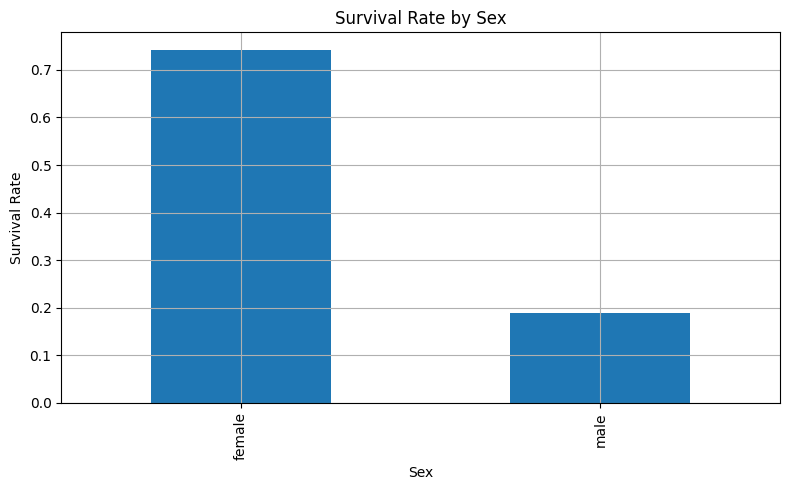


--- Survival Rate by Pclass ---


/tmp/ipython-input-2989953677.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rates = df_fe.groupby(c).apply(safe_rate).sort_values(ascending=False)


,0
Pclass,
1,0.629630
2,0.472826
3,0.242363


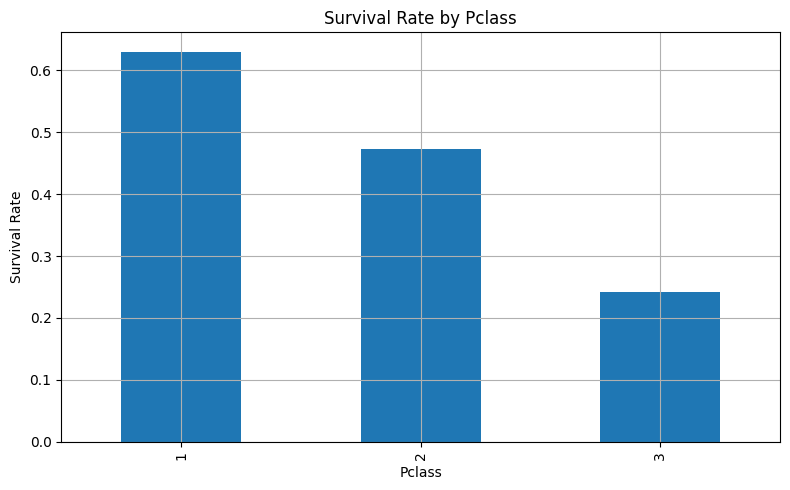


--- Survival Rate by Embarked ---


/tmp/ipython-input-2989953677.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rates = df_fe.groupby(c).apply(safe_rate).sort_values(ascending=False)


,0
Embarked,
C,0.553571
Q,0.389610
S,0.336957


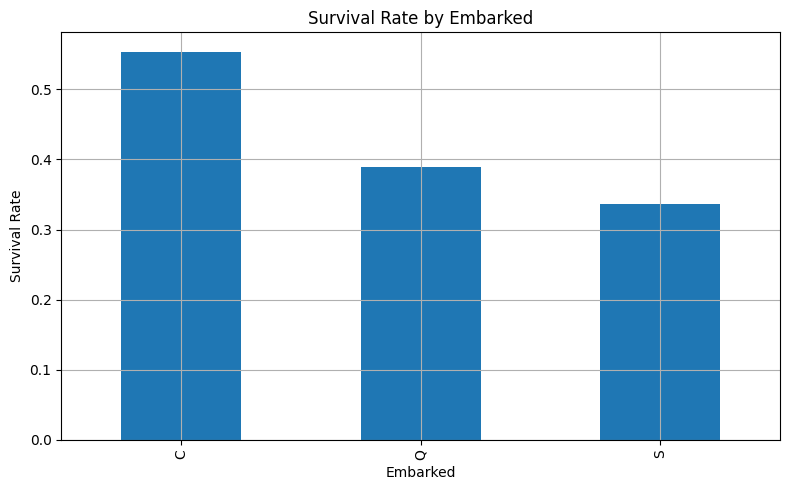


--- Survival Rate by Title ---


/tmp/ipython-input-2989953677.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rates = df_fe.groupby(c).apply(safe_rate).sort_values(ascending=False)


,0
Title,
the Countess,1.000000
Mrs,0.793651
Miss,0.702703
Master,0.575000
Noble,0.500000
Dr,0.428571
Officer,0.400000
Mr,0.156673
Clergy,0.000000


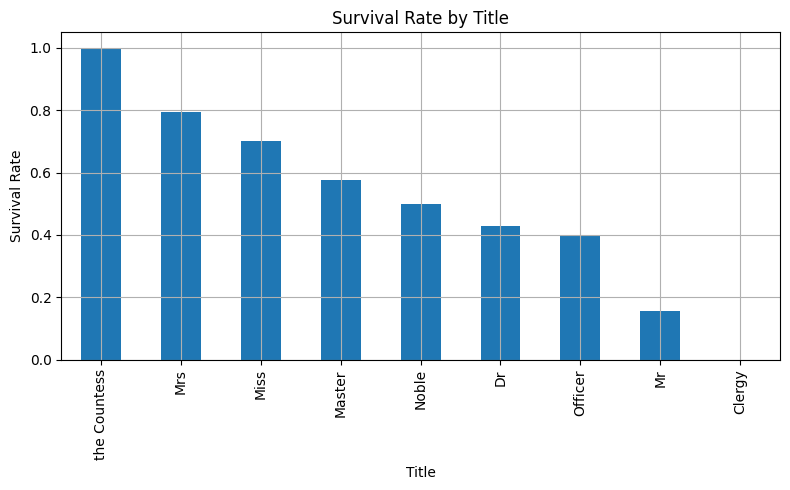


--- Survival Rate by AgeBin ---


/tmp/ipython-input-2989953677.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = df_fe.groupby(c).apply(safe_rate).sort_values(ascending=False)
/tmp/ipython-input-2989953677.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rates = df_fe.groupby(c).apply(safe_rate).sort_values(ascending=False)


,0
AgeBin,
Child,0.579710
Teen,0.428571
Adult,0.423237
YoungAdult,0.355556
MidAge,0.343750
Senior,NaN


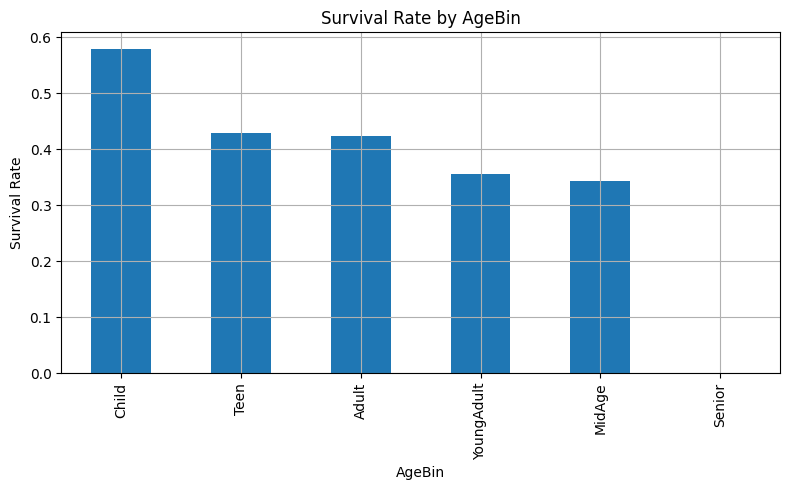


--- Survival Rate by Deck ---


/tmp/ipython-input-2989953677.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rates = df_fe.groupby(c).apply(safe_rate).sort_values(ascending=False)


,0
Deck,
D,0.757576
E,0.750000
B,0.744681
F,0.615385
C,0.593220
G,0.500000
A,0.466667
U,0.299854
T,0.000000


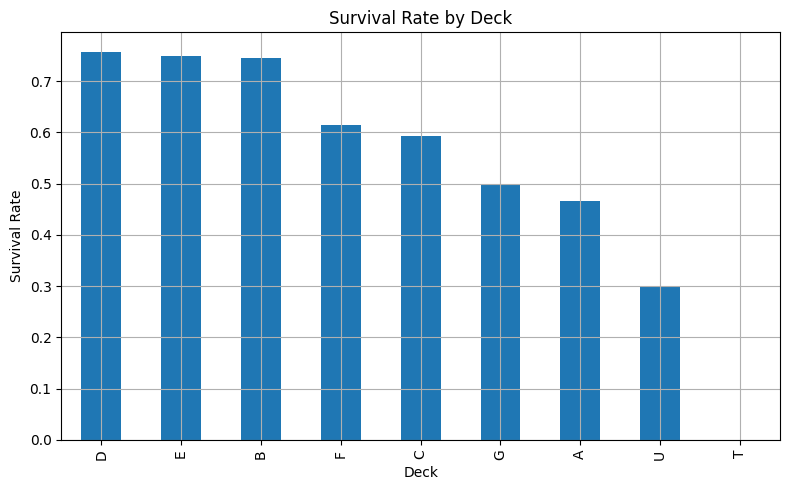


--- Survival Rate by IsAlone ---


/tmp/ipython-input-2989953677.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rates = df_fe.groupby(c).apply(safe_rate).sort_values(ascending=False)


,0
IsAlone,
0,0.505650
1,0.303538


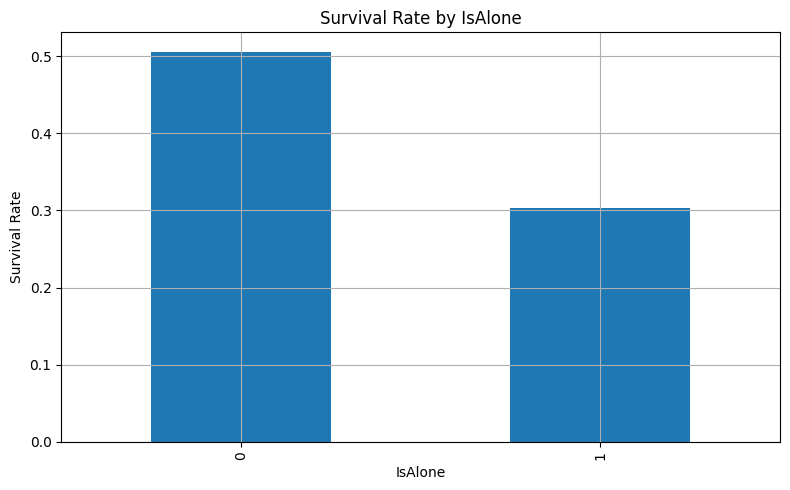

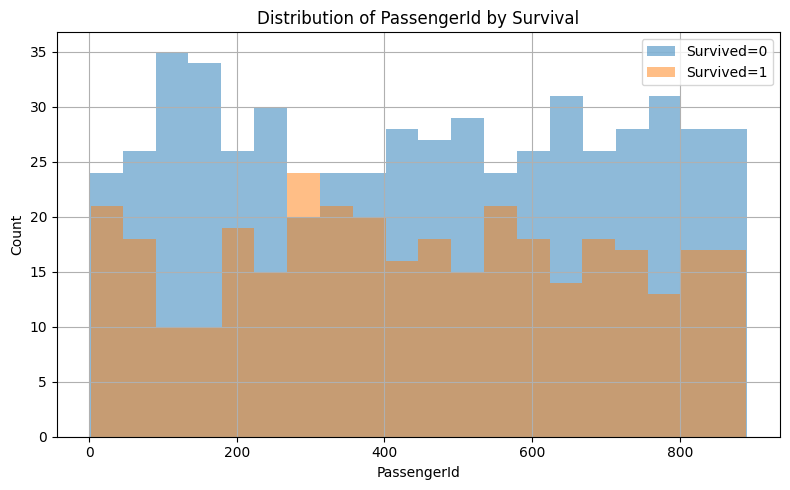

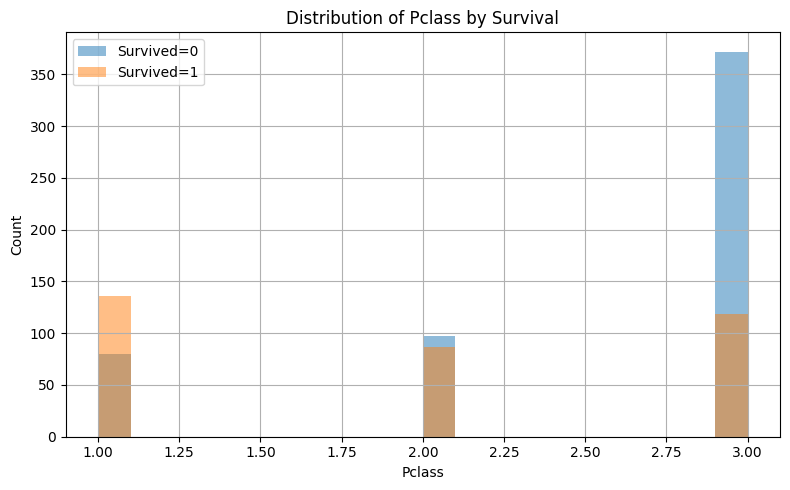

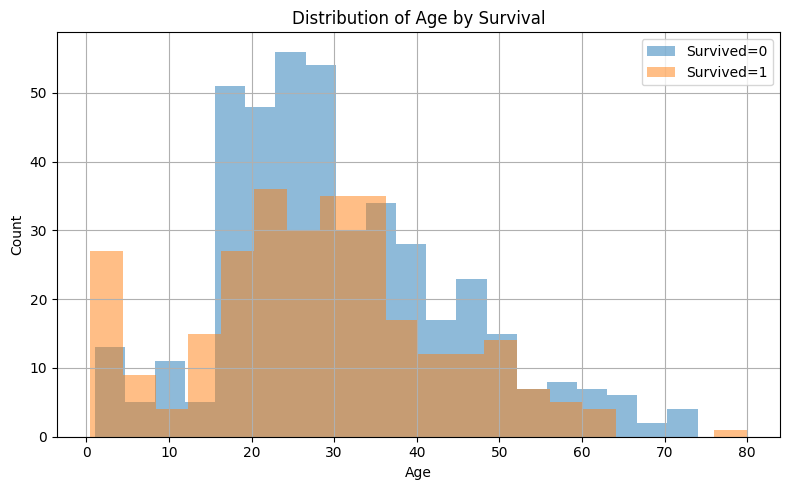

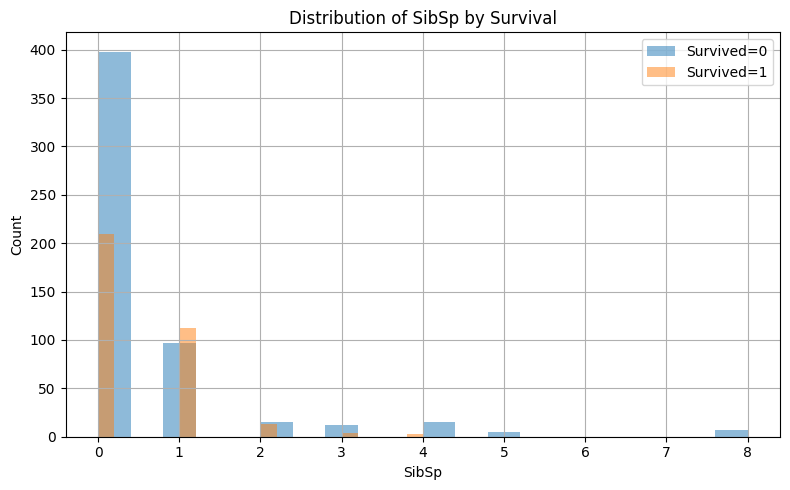

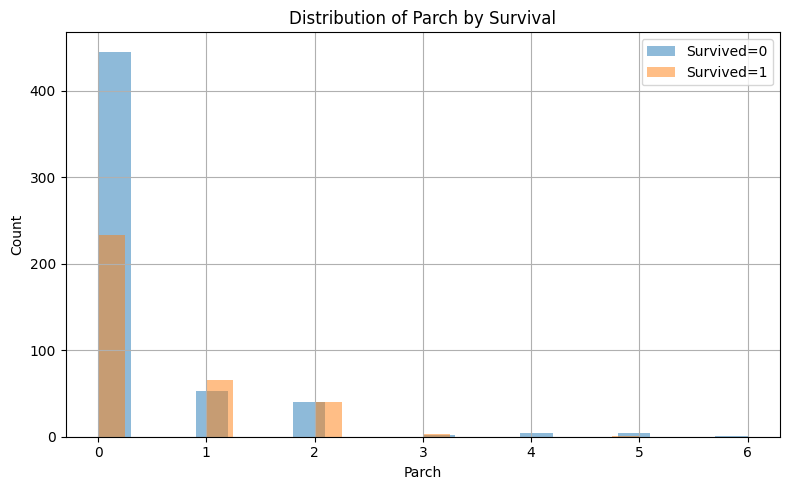

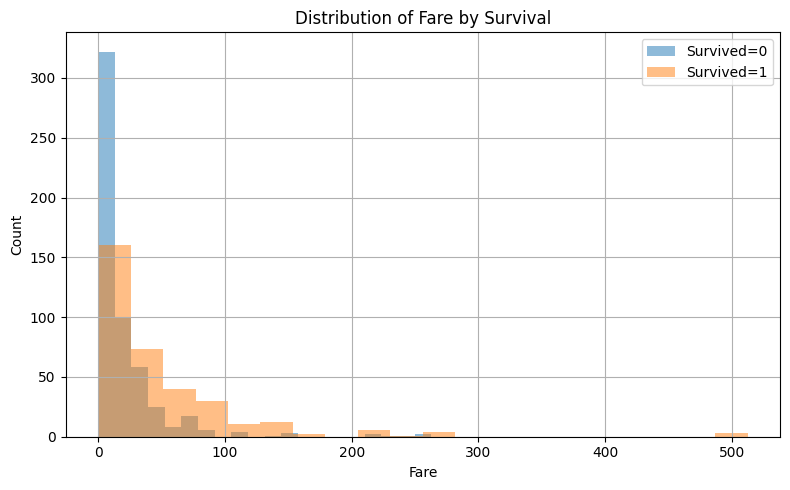

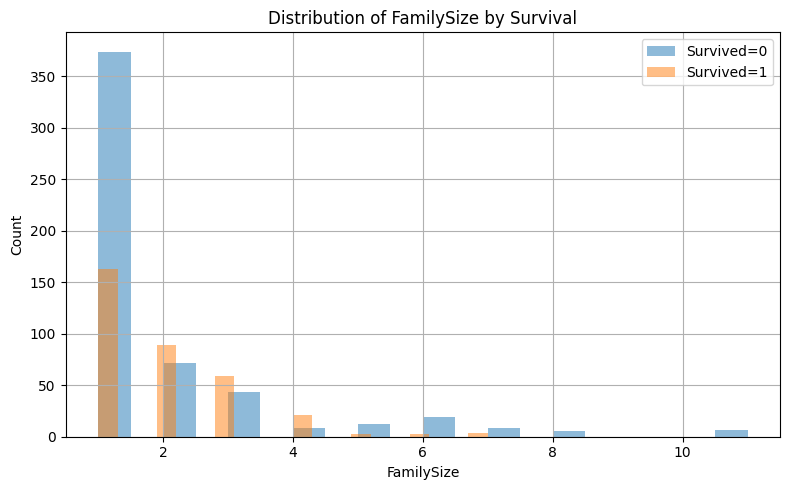

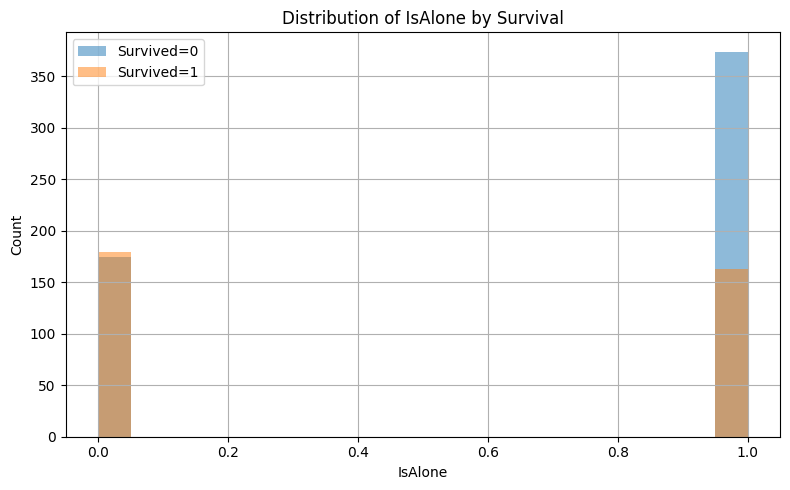

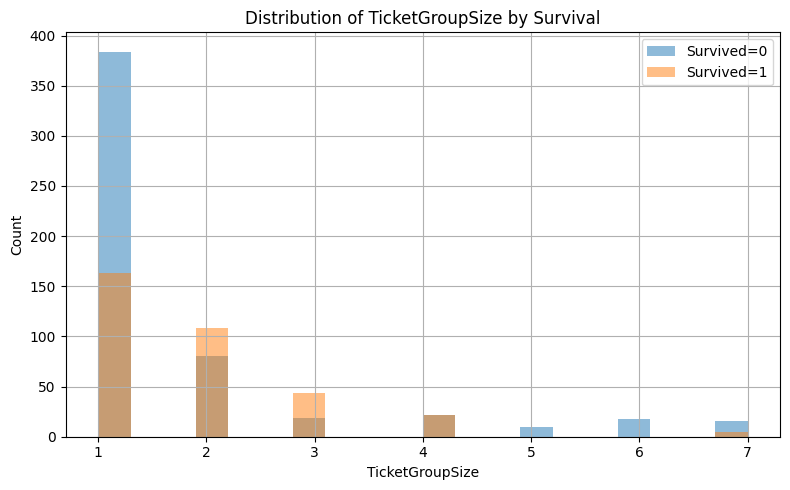

In [11]:

def safe_rate(group, target="Survived"):
    if target not in group.columns:
        return np.nan
    return group[target].mean()

# Compute and plot survival rates for available categorical features
cat_candidates = ["Sex","Pclass","Embarked","Title","AgeBin","Deck","IsAlone"]
cat_cols = [c for c in cat_candidates if c in df_fe.columns]

for c in cat_cols:
    rates = df_fe.groupby(c).apply(safe_rate).sort_values(ascending=False)
    print(f"\n--- Survival Rate by {c} ---")
    display(rates)

    # Bar chart (one plot per chart)
    plt.figure()
    rates.plot(kind="bar")
    plt.title(f"Survival Rate by {c}")
    plt.ylabel("Survival Rate")
    plt.xlabel(c)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"survival_rate_by_{c}.png", dpi=200)
    plt.show()

# For numeric columns, compare distributions by Survived
num_candidates = [c for c in df_fe.select_dtypes(include=[np.number]).columns if c != "Survived"]
for c in num_candidates:
    if "Survived" not in df_fe.columns:
        continue
    plt.figure()
    for s in sorted(df_fe["Survived"].dropna().unique()):
        series = df_fe.loc[df_fe["Survived"] == s, c].dropna()
        # Histogram
        plt.hist(series, alpha=0.5, bins=20, label=f"Survived={int(s)}")
    plt.title(f"Distribution of {c} by Survival")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"dist_{c}_by_survival.png", dpi=200)
    plt.show()


###Interpretations







Survival rate by Sex

Result: Female 74.2% vs Male 18.9%.

Interpretation: Strongest single separator; evacuation priority and social norms drove much higher survival for females.


---


Survival rate by Pclass

Result: 1st: 63.0%, 2nd: 47.3%, 3rd: 24.2%.

Interpretation: Clear gradient—cabin location and access pathways favored higher classes.


---


Survival rate by Embarked

Result: C: 55.4%, Q: 39.0%, S: 33.7%.

Interpretation: Port of embarkation co-varies with class mix and possibly cabin placement; treat as a proxy feature with class confounding.


---


Survival rate by AgeBin

Bins: Child (0–12), Teen (12–18), YoungAdult (18–30), Adult (30–50), MidAge (50–80); Senior bin is empty in this dataset setup.

Result: Child 58.0%, Teen 42.9%, Adult 42.3%, YoungAdult 35.6%, MidAge 34.4%.

Interpretation: Children fare better (priority/assistance). Adults/teens moderate; mid-age dips slightly. Note: ~20% of ages are missing—imputation affects these rates.


---


Survival rate by Deck (from Cabin; “U” = unknown)

Result (ordered): D 75.8%, E 75.0%, B 74.5%, F 61.5%, C 59.3%, G 50.0%, A 46.7%, U 30.0%, T 0.0% (rare).

Interpretation: Higher decks nearer boats/exits show better survival. The U (Unknown) group is large (because Cabin is 77% missing) and has low survival—likely lower-deck/unknown placement; handle with caution due to missingness bias and tiny samples for some decks.


---


Survival rate by IsAlone

Result: Not alone (0): 50.6%, Alone (1): 30.4%.

Interpretation: Being with companions correlates with higher survival—groups can coordinate/help reach muster points.


---


Numeric distributions by Survived (histograms)

(Compare shapes/centers for Survived=0 vs 1.)

**Fare:** Survivors have much higher fares (mean 48.40 vs 22.12).

Interpretation: Proxy for class and cabin proximity—strong positive association with survival.

**Pclass (numeric 1–3):** Survivors trend toward lower numeric values (mean 1.95 vs 2.53) → more 1st/2nd class among survivors.

**Age:** Survivors are slightly younger on average (28.34 vs 30.63).

Interpretation: Small but visible shift; missing-age handling will influence this.

**SibSp / Parch:** Survivors show slightly fewer siblings/spouses (SibSp 0.47 vs 0.55) but slightly more parents/children (Parch 0.46 vs 0.33).

Interpretation: Travel group composition matters—families with children may have been prioritized; very large groups can slow movement.


## Survival Improvement Plan

What else could be done to improve the survival rate based on data?


###**Data-Linked Recommendations**

**Executive summary (from your charts):**

-Sex: Female 74.2% vs Male 18.9% survival

-Class: 1st 63.0%, 2nd 47.3%, 3rd 24.2%

-Deck (cabin proxy): Upper decks (e.g., D/E/B ≈ ~75%) vs Unknown deck “U” 30.0%

-Group status: Not-alone 50.6% vs Alone 30.4%

-Age: Children 58.0% > teens/adults (~35–43% range)

*These gaps point to access, guidance, and loading discipline as the biggest levers to increase survival.*

**1) Structured Evacuation Priority**

- What the chart says: Females (74.2%) and children (58.0%) survive far more than males/older groups.
- Action: Enforce priority queues—Women → Children → Elderly → Mobility-impaired → Others—across all classes/decks, with checkpoint marshals preventing queue-jumping.
- Why it works: Aligns flow with groups showing the largest uplift in the data.
-Plots: Survival by Sex, Survival by AgeBin.

**2) Crew-Led Wayfinding (Stairwells & Hubs)**

- What the chart says: Upper-deck passengers (Deck D/E/B ≈ ~75%) out-survive Unknown deck (U) 30%, implying distance/access matter.
- Action: Station trained crew at stairwells and corridors with megaphones/hand signals; add glow-path markers and large arrows to boats.
- Why it works: Reduces “lost time” for lower/unknown-deck passengers.
- Plots: Survival by Deck.

**3) Muster Drills & Clear Instructions**

- What the chart says: Differences by Embarked (C 55.4% vs S 33.7%) and Title suggest language/role effects.
- Action: Mandatory muster drill in first 24h; multilingual pictogram cards at cabins/muster points; periodic PA reminders.
- Why it works: Improves early compliance and reduces confusion.
- Plots: Survival by Embarked, Survival by Title.


**4) Equitable Access for Lower Decks / 3rd Class**

- What the chart says: Survival drops from 63.0% (1st) → 24.2% (3rd).
- Action: Auto-unlock class barriers on alarm; staggered release by deck (short timed waves); guarantee equal access windows to each boat.
- Why it works: Neutralizes structural disadvantages and balances loading.
- Plots: Survival by Pclass.


**5) Group Management (Families & Buddies)**

- What the chart says: Not-alone 50.6% vs Alone 30.4%—moving as a unit helps.
- Action: Family tagging (keep together) and a buddy system for solo travelers at boarding; assign runners to fetch stragglers from tagged groups.
- Why it works: Cuts search/hesitation time and keeps groups moving.
- Plots: Survival by IsAlone.


**6) Equipment Distribution & “Vest-Before-Deck”**

  - What the chart says: Loading delays likely penalize lower-survival groups (Pclass=3, U-Deck).
  - Action: Pre-position life vests and portable lights on every deck section; require vest fitted at muster so boat loading is fast.
  - Why it works: Removes gear bottlenecks at boats; speeds boarding for those far from boats.
  - Plots: Deck & Class charts as rationale.

**7) Real-Time Reassignment to Prevent Underfilled Departures**

- What your KPIs imply: Underfilled boats cause avoidable losses.(~50% at 90% fill vs actual)
- Action: A loadmaster at each station sets a fill target; if a boat is below target at T-10s, pull from the next queue immediately.
- Why it works: Converts idle capacity into saved lives—no extra boats required.
- Plots/KPIs: Throughput & cumulative evacuees curve


**8) Crew Role Cards & Panic-Resilient Drills**

  - What the chart says: The largest gaps are systematic (sex/class/deck), not random—coordination fixes them.
  - Action: Issue role cards (who/where/when) and run crowd-flow drills; pre-place choke-point marshals, stairwell escorts, runners.
  - Why it works: Sustains throughput under stress and ensures consistency across decks.
  - Plots: All above—turns pattern-driven fixes into reliable practice.